# VASA Spatial Analysis Pipeline

Runs the full spatial analysis on a multi-condition dataset of refined VASA label images.
Computes contact graph metrics, graph topology control, Ripley's K, and geometric metrics.

**Outputs per sample:**
- Per-cell metrics CSV (`_VASA_neighbor_metrics.csv`)
- Per-sample summary CSV (`_VASA_neighbor_summary.csv`)
- Metric-painted label maps (TIFF)

**Requires:** `spatial_analysis_tools.py` in the same directory.

In [37]:
import importlib
import spatial_analysis_tools as sat
importlib.reload(sat)

import tifffile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style='whitegrid', font_scale=1.1)

## 1. Configuration

In [38]:
px_size = [0.25, 0.14, 0.14]       # Z, Y, X in micrometers
NOISE_THRESHOLD = 5                 # minimum shared faces to count as contact
N_GRAPH_ITER   = 200                # config-model iterations (1000 for final; 200 for quick runs)
N_RIPLEY_SIM   = 100                # Monte Carlo CSR simulations for Ripley envelope

# --- INPUT: list of folders and matching condition labels ---
folders    = [
    'Z:\\Mikala\\connectivity\\09012025\\',
    'Z:\\Mikala\\connectivity\\09012025\\',
    'Z:\\Mikala\\connectivity\\09012025\\',
    'Z:\\Mikala\\connectivity\\09012025\\',
    'Z:\\Mikala\\connectivity\\09012025\\',

]
conditions = [
    'control1','dlg1OE1','mtlRNAi','nrg167OE2',
]

# --- OUTPUT directory for exported CSVs and painted maps ---
output_dir = 'Z:\\Mikala\\connectivity\\results\\'
os.makedirs(output_dir, exist_ok=True)

## 2. Batch Analysis

Iterates over all `*masks_refined.tif` files, runs the full analysis per sample.

In [39]:
all_cell_metrics = []
all_summaries    = []
ripley_per_sample = []      # stores per-sample Ripley arrays for plotting
comp_sizes_per_sample = []  # stores component size lists for histogram

for folder, condition in zip(folders, conditions):
    mask_files = sorted([f for f in os.listdir(folder)
                 if f.endswith('masks_refined.tif') and condition in f])

    #mask_files = sorted([
    #    f for f in os.listdir(folder)
    #    if f.endswith('masks_refined.tif')
    #])

    print(f'\n=== {condition}: {len(mask_files)} file(s) in {folder} ===')
    
    for fname in mask_files:
        dataset = fname.split('_ch')[0]
        print(f'  Processing: {fname}')
        label_image = tifffile.imread(os.path.join(folder, fname))

        # --- Contact graph analysis ---
        cell_metrics, G, summary = sat.analyzeVASANeighbors(
            label_image, noise_threshold=NOISE_THRESHOLD, px_size=px_size)

        # --- Graph topology null test ---
        control = sat.computeGraphControl(G, n_iterations=N_GRAPH_ITER)

        # --- Ripley's K/L ---
        ripley = sat.computeRipleysK(
            cell_metrics, px_size, label_image.shape,
            n_simulations=N_RIPLEY_SIM,
            mean_diameter_um=summary['mean_diameter_um'])

        # --- Geometric metrics ---
        geom = sat.computeGeometricMetrics(cell_metrics, label_image, px_size)

        # --- Export per-sample CSVs ---
        sat.exportVASANeighborMetrics(cell_metrics, summary, output_dir, dataset)

        # --- Accumulate cell-level data ---
        cell_metrics['dataset']   = dataset
        cell_metrics['condition'] = condition
        all_cell_metrics.append(cell_metrics)

        comp_sizes_per_sample.append({
            'dataset': dataset, 'condition': condition,
            'sizes': summary['component_sizes']
        })

        # --- Accumulate sample-level summary ---
        row = {'dataset': dataset, 'condition': condition}
        row.update({k: v for k, v in summary.items() if k != 'component_sizes'})
        # graph control: prefix observed metrics with 'ctrl_'
        row.update({'ctrl_' + k: v for k, v in control['observed'].items()})
        row.update({'ctrl_p_' + k: v for k, v in control['p_values'].items()})
        # geometric metrics: prefix with 'geom_'
        row.update({'geom_' + k: v for k, v in geom.items()})
        all_summaries.append(row)

        # --- Accumulate Ripley arrays ---
        ripley_per_sample.append({
            'dataset': dataset, 'condition': condition, **ripley
        })
        
df_cells   = pd.concat(all_cell_metrics, ignore_index=True)
df_summary = pd.DataFrame(all_summaries)

print(f'\nDone. {len(df_cells)} total cells across {len(df_summary)} samples.')


=== control1: 11 file(s) in Z:\Mikala\connectivity\09012025\ ===
  Processing: 09012025_control1_dapi_488_555_647_ovary10_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 153 cells, 1 components (LCC=153), 0 isolated, FI=0.000
[computeGraphControl] p-values: mean_clustering=0.0000, n_components=1.0000, largest_component=0.9400, cpl=1.0000, cpl_norm=1.0000  SW=10.043
[computeRipleysK] Computed K/L for 153 cells over r=[0, 16.2] um
[computeGeometricMetrics] Rg=22.4 um, R_eq=17.9 um, Rg_norm=1.249, S/V=0.7891 um^-1, S/V_norm=4.714
  Processing: 09012025_control1_dapi_488_555_647_ovary11_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 120 cells, 2 components (LCC=119), 1 isolated, FI=0.008
[computeGraphControl] p-values: mean_clustering=0.0000, n_components=1.0000, largest_component=0.9450, cpl=1.0000, cpl_norm=1.0000  SW=7.251
[computeRipleysK] Computed K/L for 120 cells over r=[0, 14.9] um
[computeGeometricMetrics] Rg=18.7 um, R_eq=15.7 um, Rg_norm=1.192, S/V=0.7754 um^-1, S/

## 3. Results Overview

In [40]:
# Key summary columns displayed per sample
display_cols = [
    'dataset', 'condition',
    'n_cells', 'n_components', 'lcc_size', 'fragmentation_index',
    'mean_k', 'std_k', 'frac_isolated',
    'mean_CC_defined', 'frac_CC_undefined',
    'mean_diameter_um', 'mean_volume_um3',
    'ctrl_cpl', 'ctrl_cpl_norm', 'ctrl_sw',
    'ctrl_p_mean_clustering', 'ctrl_p_cpl',
    'geom_rg_um', 'geom_rg_norm', 'geom_sv_ratio', 'geom_sv_ratio_norm',
]
display_cols = [c for c in display_cols if c in df_summary.columns]
df_summary[display_cols].round(3)

,dataset,condition,n_cells,n_components,lcc_size,fragmentation_index,mean_k,std_k,frac_isolated,mean_CC_defined,...,mean_volume_um3,ctrl_cpl,ctrl_cpl_norm,ctrl_sw,ctrl_p_mean_clustering,ctrl_p_cpl,geom_rg_um,geom_rg_norm,geom_sv_ratio,geom_sv_ratio_norm
0,09012025_control1_dapi_488_555_647_ovary10,control1,153,1,153,0.000,4.026,1.559,0.000,0.379,...,157.544,6.989,1.389,10.043,0.0,1.0,22.379,1.249,0.789,4.714
1,09012025_control1_dapi_488_555_647_ovary11,control1,120,2,119,0.008,4.450,1.936,0.008,0.415,...,133.909,5.642,1.180,7.251,0.0,1.0,18.653,1.192,0.775,4.046
2,09012025_control1_dapi_488_555_647_ovary1,control1,153,2,152,0.007,4.418,2.050,0.007,0.414,...,139.699,6.073,1.209,8.960,0.0,1.0,18.450,1.072,0.775,4.446
3,09012025_control1_dapi_488_555_647_ovary2,control1,131,1,131,0.000,4.656,2.132,0.000,0.457,...,187.973,5.857,1.201,7.563,0.0,1.0,19.245,1.066,0.654,3.934
4,09012025_control1_dapi_488_555_647_ovary3,control1,135,4,131,0.030,4.222,1.931,0.015,0.452,...,155.593,6.221,1.276,9.385,0.0,1.0,19.248,1.125,0.738,4.213
5,09012025_control1_dapi_488_555_647_ovary4,control1,118,5,102,0.136,3.949,1.904,0.000,0.439,...,172.796,6.712,1.451,7.736,0.0,1.0,19.410,1.145,0.747,4.222
6,09012025_control1_dapi_488_555_647_ovary5,control1,141,3,139,0.014,4.142,1.653,0.014,0.411,...,150.564,7.137,1.446,8.629,0.0,1.0,18.686,1.088,0.781,4.470
7,09012025_control1_dapi_488_555_647_ovary6,control1,130,2,129,0.008,4.154,1.907,0.008,0.427,...,134.917,7.052,1.451,6.989,0.0,1.0,17.643,1.095,0.771,4.141
8,09012025_control1_dapi_488_555_647_ovary7,control1,123,3,111,0.098,4.341,1.912,0.000,0.449,...,121.565,6.046,1.284,7.612,0.0,1.0,18.149,1.188,0.800,4.078
9,09012025_control1_dapi_488_555_647_ovary8,control1,165,3,163,0.012,3.927,1.725,0.012,0.402,...,154.123,7.331,1.439,10.469,0.0,1.0,21.548,1.181,0.781,4.747


## 4. Per-Cell Distributions

Each dot/violin represents one cell. Useful for seeing how the distribution shape changes across conditions.

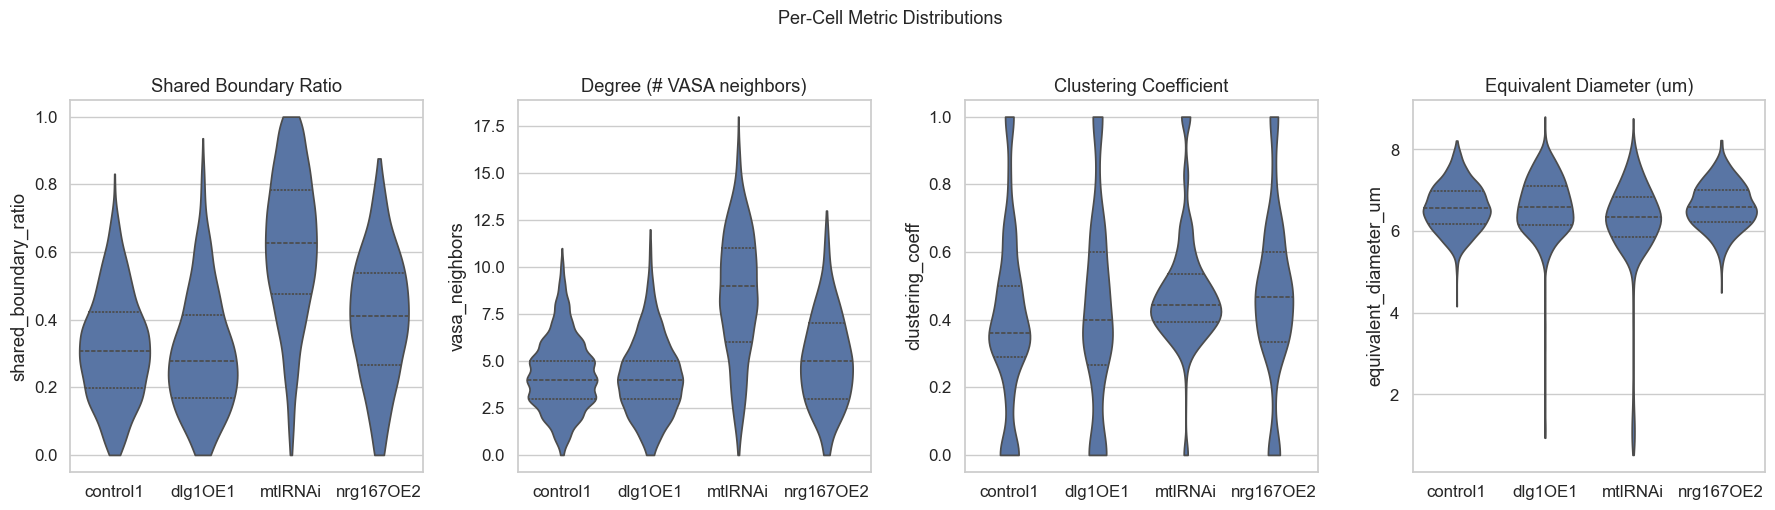

In [41]:
# Violin plots — per-cell metrics
cell_metrics_to_plot = [
    ('shared_boundary_ratio', 'Shared Boundary Ratio'),
    ('vasa_neighbors',        'Degree (# VASA neighbors)'),
    ('clustering_coeff',      'Clustering Coefficient'),
    ('equivalent_diameter_um','Equivalent Diameter (um)'),
]

fig, axes = plt.subplots(1, len(cell_metrics_to_plot),
                         figsize=(4.5 * len(cell_metrics_to_plot), 5))
if len(cell_metrics_to_plot) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, cell_metrics_to_plot):
    sns.violinplot(data=df_cells, x='condition', y=col, ax=ax, cut=0, inner='quartile')
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Per-Cell Metric Distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'per_cell_violins.pdf'), bbox_inches='tight')
plt.show()

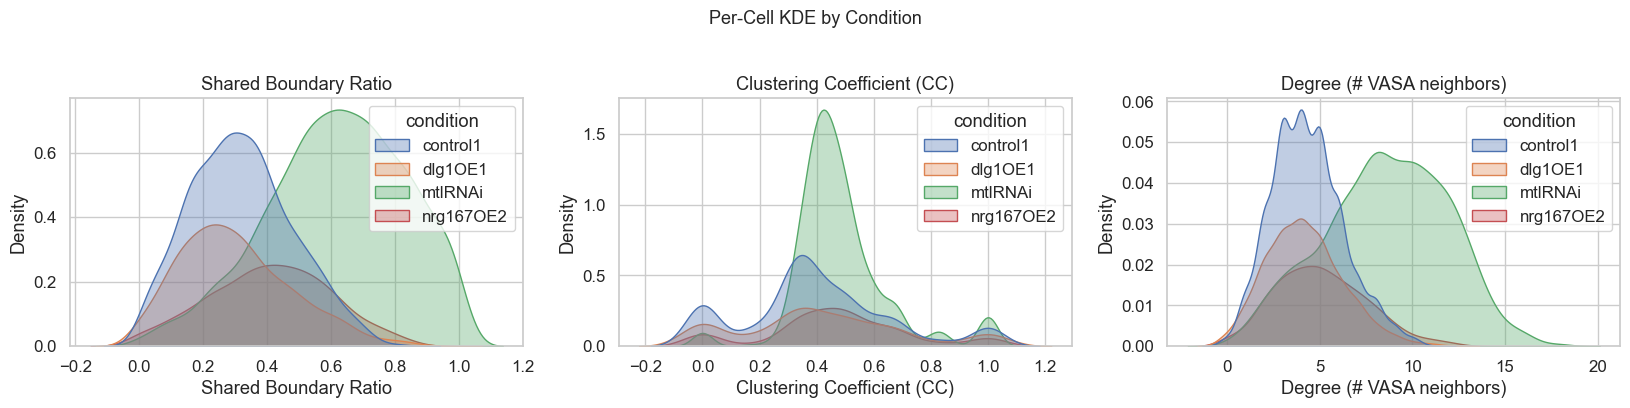

In [42]:
# KDE overlays — distribution shape per condition
kde_metrics = [
    ('shared_boundary_ratio', 'Shared Boundary Ratio'),
    ('clustering_coeff',      'Clustering Coefficient (CC)'),
    ('vasa_neighbors',        'Degree (# VASA neighbors)'),
]

fig, axes = plt.subplots(1, len(kde_metrics), figsize=(5.5 * len(kde_metrics), 4))
if len(kde_metrics) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, kde_metrics):
    sns.kdeplot(data=df_cells, x=col, hue='condition', fill=True, alpha=0.35, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)

plt.suptitle('Per-Cell KDE by Condition', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'per_cell_kde.pdf'), bbox_inches='tight')
plt.show()

## 5. Degree Distribution

Degree distribution (number of VASA neighbors per cell) — discrete histogram per condition.

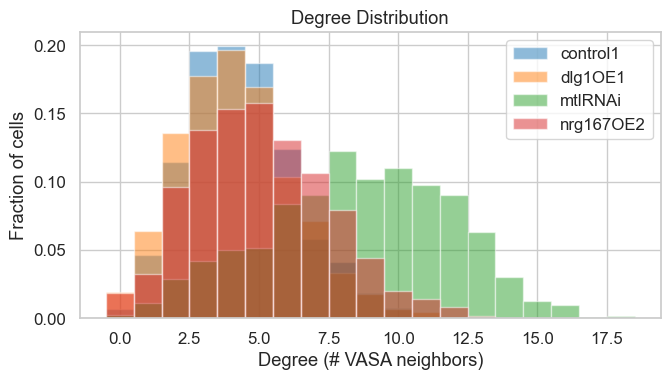

           mean   std
condition            
control1   4.32  1.93
dlg1OE1    4.18  2.08
mtlRNAi    8.57  3.34
nrg167OE2  5.07  2.46


In [43]:
fig, ax = plt.subplots(figsize=(7, 4))

conditions_unique = df_cells['condition'].unique()
palette = sns.color_palette('tab10', len(conditions_unique))

for cond, color in zip(conditions_unique, palette):
    subset = df_cells[df_cells['condition'] == cond]['vasa_neighbors']
    bins = np.arange(subset.max() + 2) - 0.5
    ax.hist(subset, bins=bins, density=True, alpha=0.5, color=color, label=cond)

ax.set_xlabel('Degree (# VASA neighbors)')
ax.set_ylabel('Fraction of cells')
ax.set_title('Degree Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'degree_distribution.pdf'), bbox_inches='tight')
plt.show()

# Print mean ± std degree per condition
print(df_cells.groupby('condition')['vasa_neighbors'].agg(['mean', 'std']).round(2))

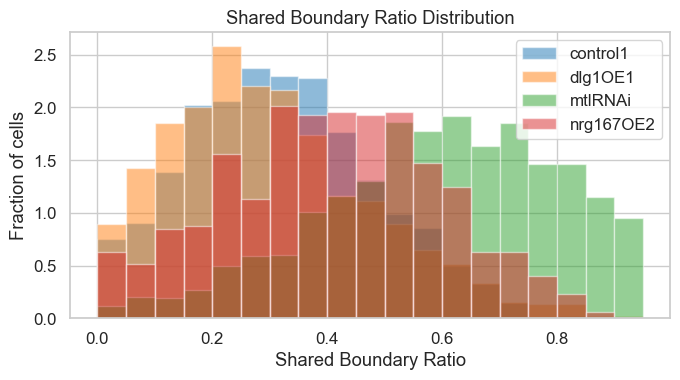

           mean   std
condition            
control1   0.32  0.16
dlg1OE1    0.30  0.18
mtlRNAi    0.62  0.22
nrg167OE2  0.41  0.19


In [48]:
fig, ax = plt.subplots(figsize=(7, 4))

conditions_unique = df_cells['condition'].unique()
palette = sns.color_palette('tab10', len(conditions_unique))

for cond, color in zip(conditions_unique, palette):
    subset = df_cells[df_cells['condition'] == cond]['shared_boundary_ratio']
    #bins = np.arange(subset.max() + 0.1) - 0.5
    bins = np.arange(0,1,0.05)
    ax.hist(subset, bins=bins, density=True, alpha=0.5, color=color, label=cond)

ax.set_xlabel('Shared Boundary Ratio')
ax.set_ylabel('Fraction of cells')
ax.set_title('Shared Boundary Ratio Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'shared_boundary_distribution.pdf'), bbox_inches='tight')
plt.show()

# Print mean ± std degree per condition
print(df_cells.groupby('condition')['shared_boundary_ratio'].agg(['mean', 'std']).round(2))

## 6. Component Size Distribution

Distribution of connected component sizes across all samples.

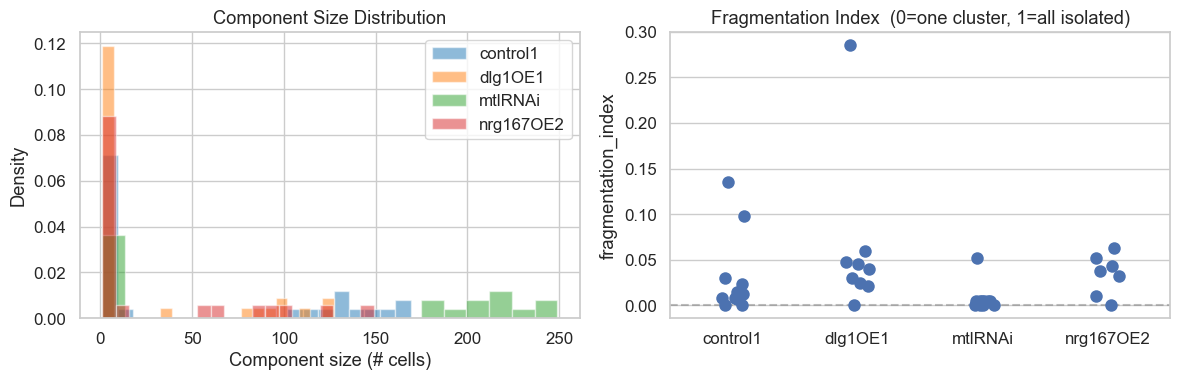

In [49]:
# Flatten component sizes into a DataFrame for plotting
comp_rows = []
for entry in comp_sizes_per_sample:
    for sz in entry['sizes']:
        comp_rows.append({'condition': entry['condition'],
                          'dataset': entry['dataset'],
                          'component_size': sz})
df_comp = pd.DataFrame(comp_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of component sizes
for cond, color in zip(conditions_unique, palette):
    subset = df_comp[df_comp['condition'] == cond]['component_size']
    axes[0].hist(subset, bins=20, density=True, alpha=0.5, color=color, label=cond)
axes[0].set_xlabel('Component size (# cells)')
axes[0].set_ylabel('Density')
axes[0].set_title('Component Size Distribution')
axes[0].legend()

# Fragmentation index per sample
sns.stripplot(data=df_summary, x='condition', y='fragmentation_index',
              size=9, jitter=True, ax=axes[1])
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Fragmentation Index  (0=one cluster, 1=all isolated)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'component_sizes.pdf'), bbox_inches='tight')
plt.show()

## 7. Population-Level Summary (per sample)

Each point is one ovary. Use these plots for between-condition comparisons.

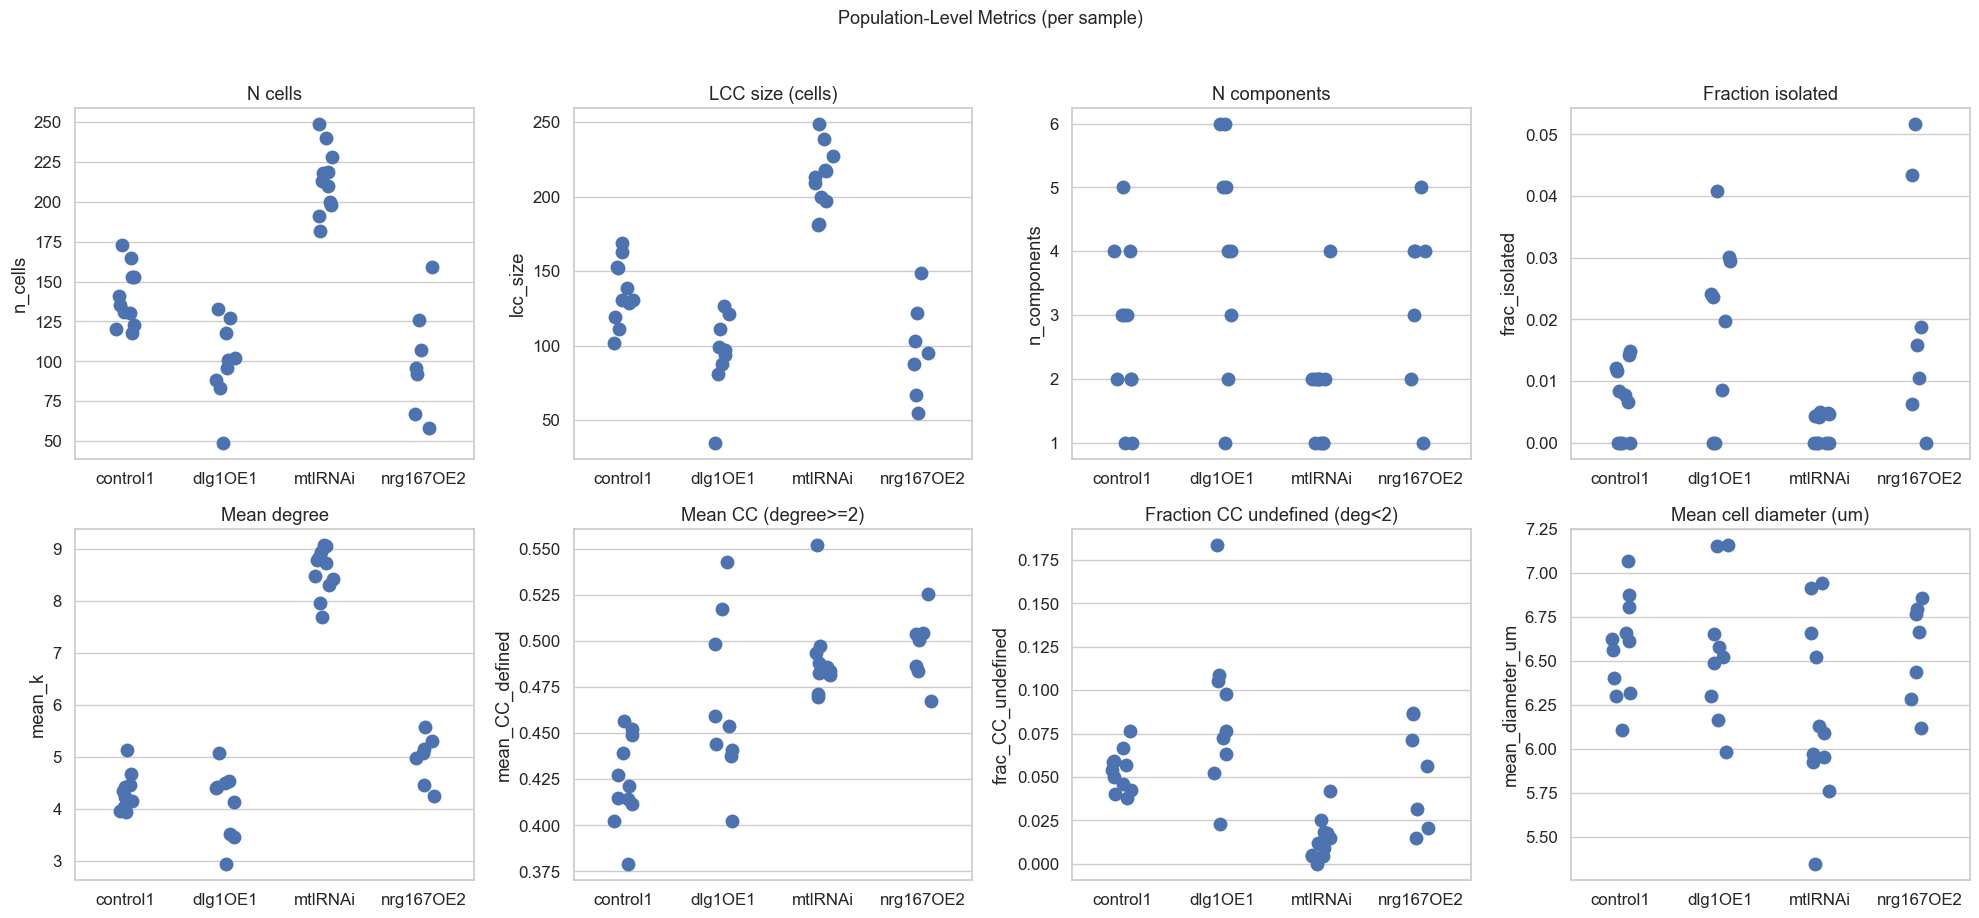

In [50]:
# Graph-level population metrics
pop_metrics = [
    ('n_cells',             'N cells'),
    ('lcc_size',            'LCC size (cells)'),
    ('n_components',        'N components'),
    ('frac_isolated',       'Fraction isolated'),
    ('mean_k',              'Mean degree'),
    ('mean_CC_defined',     'Mean CC (degree>=2)'),
    ('frac_CC_undefined',   'Fraction CC undefined (deg<2)'),
    ('mean_diameter_um',    'Mean cell diameter (um)'),
]

ncols = 4
nrows = int(np.ceil(len(pop_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, (col, label) in zip(axes, pop_metrics):
    if col not in df_summary.columns:
        ax.set_visible(False)
        continue
    sns.stripplot(data=df_summary, x='condition', y=col, size=10, jitter=True, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

for ax in axes[len(pop_metrics):]:
    ax.set_visible(False)

plt.suptitle('Population-Level Metrics (per sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'population_metrics.pdf'), bbox_inches='tight')
plt.show()

## 8. Graph Topology Control

Configuration model null test. SW > 1 = observed graph is more small-world (compact) than random.

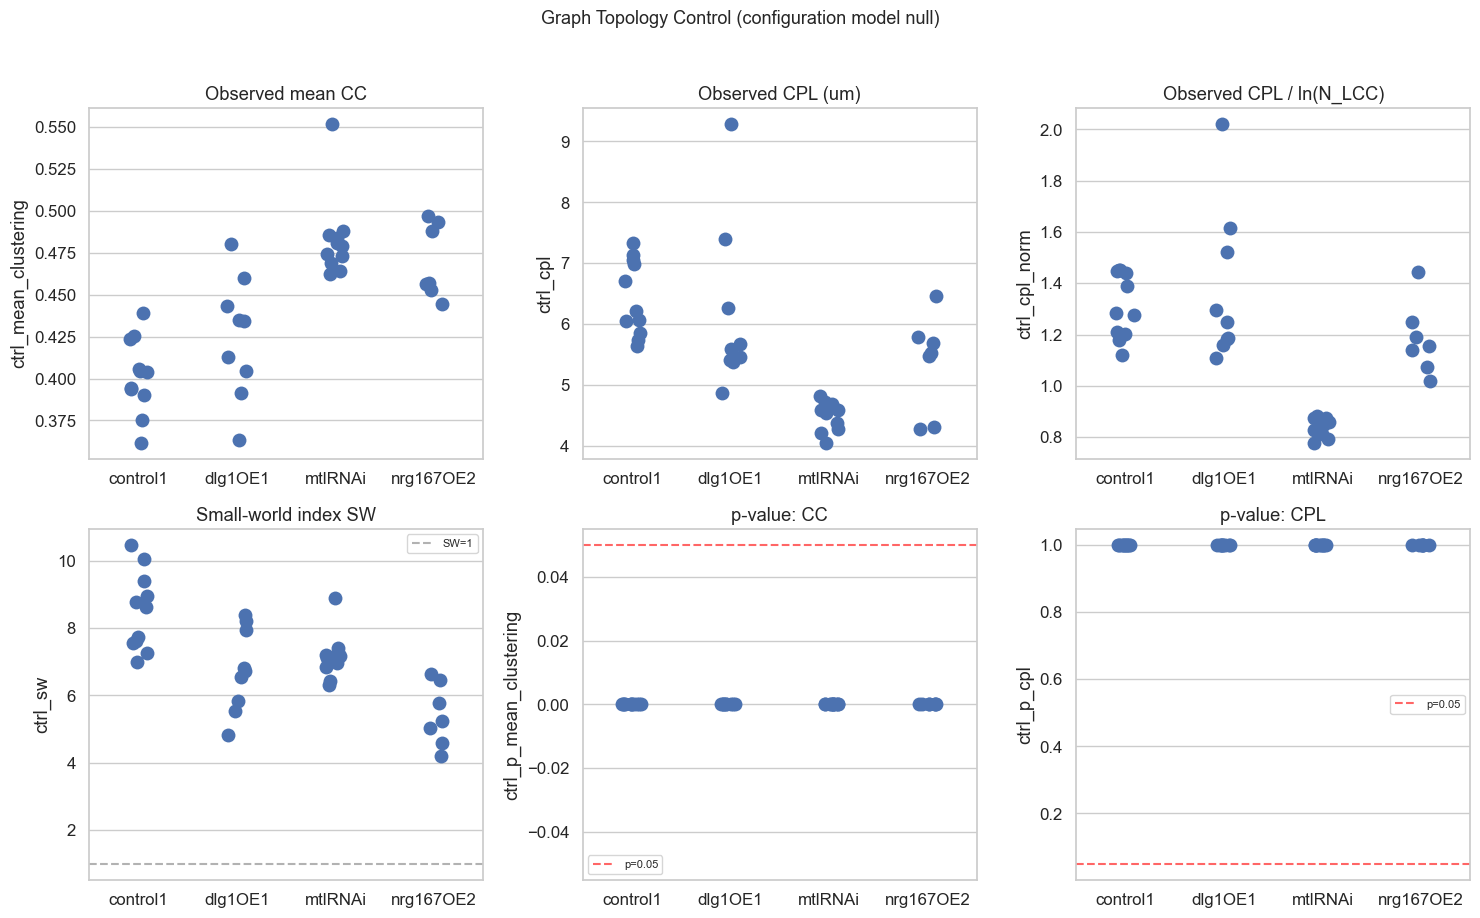

In [51]:
ctrl_metrics = [
    ('ctrl_mean_clustering', 'Observed mean CC'),
    ('ctrl_cpl',             'Observed CPL (um)'),
    ('ctrl_cpl_norm',        'Observed CPL / ln(N_LCC)'),
    ('ctrl_sw',              'Small-world index SW'),
    ('ctrl_p_mean_clustering','p-value: CC'),
    ('ctrl_p_cpl',           'p-value: CPL'),
]

ncols = 3
nrows = int(np.ceil(len(ctrl_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, (col, label) in zip(axes, ctrl_metrics):
    if col not in df_summary.columns:
        ax.set_visible(False)
        continue
    sns.stripplot(data=df_summary, x='condition', y=col, size=10, jitter=True, ax=ax)
    # Reference lines
    if 'p_value' in col or col == 'ctrl_p_cpl' or col == 'ctrl_p_mean_clustering':
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.6, label='p=0.05')
        ax.legend(fontsize=8)
    if col == 'ctrl_sw':
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='SW=1')
        ax.legend(fontsize=8)
    ax.set_title(label)
    ax.set_xlabel('')

for ax in axes[len(ctrl_metrics):]:
    ax.set_visible(False)

plt.suptitle('Graph Topology Control (configuration model null)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'graph_control.pdf'), bbox_inches='tight')
plt.show()

## 9. Geometric Metrics

- **Rg_norm**: radius of gyration / equivalent sphere radius. Compact sphere ≈ 0.775; larger = more dispersed.
- **S/V norm**: surface/volume of merged VASA domain normalized to equivalent sphere (= 1 for sphere; > 1 = more surface = less compact).

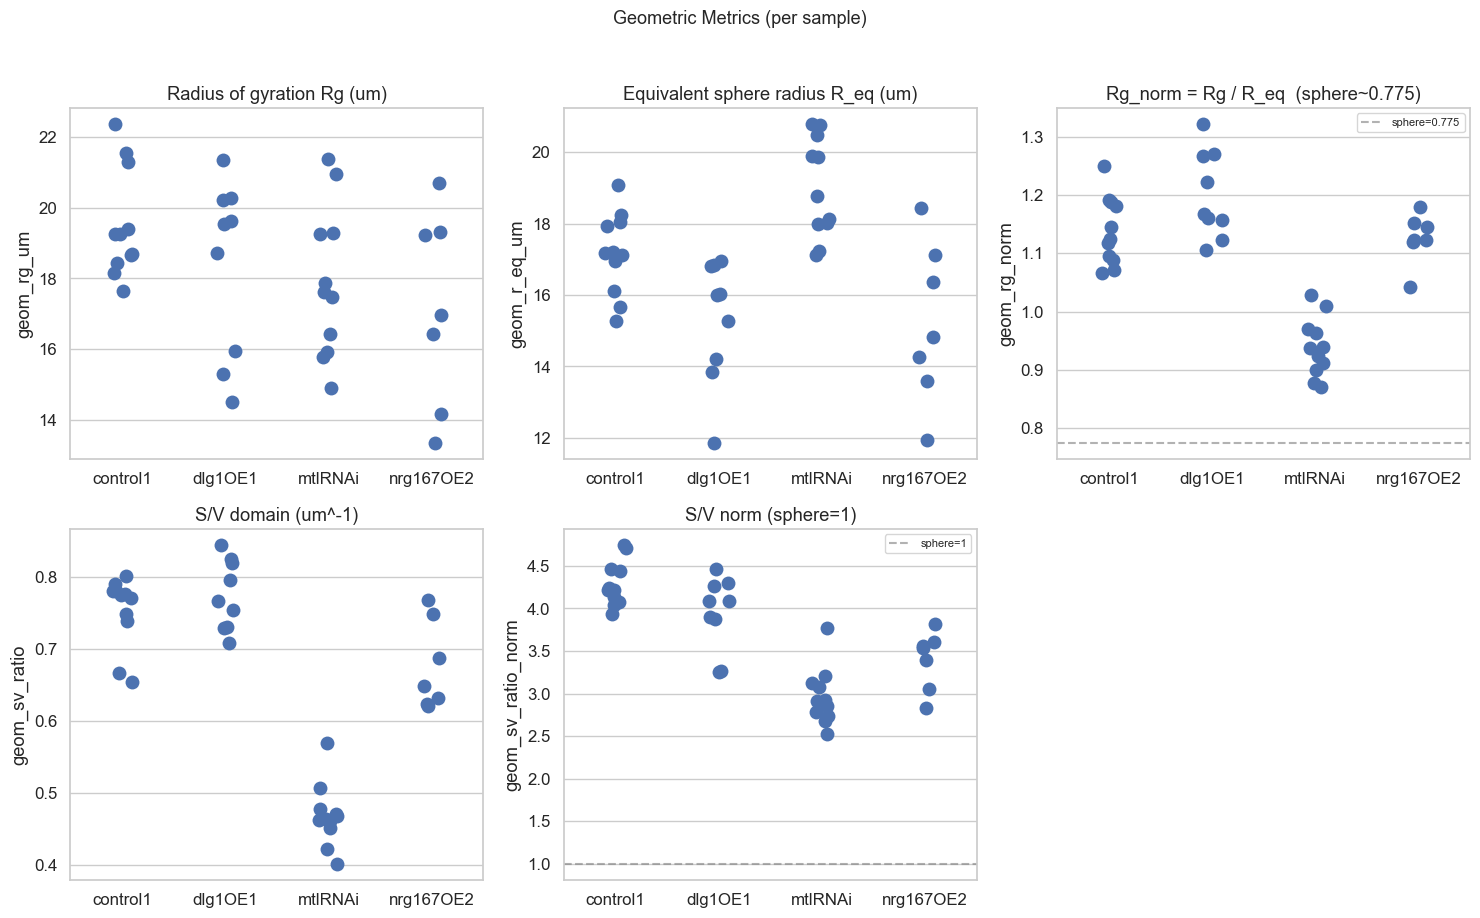

In [52]:
geom_metrics = [
    ('geom_rg_um',        'Radius of gyration Rg (um)'),
    ('geom_r_eq_um',      'Equivalent sphere radius R_eq (um)'),
    ('geom_rg_norm',      'Rg_norm = Rg / R_eq  (sphere~0.775)'),
    ('geom_sv_ratio',     'S/V domain (um^-1)'),
    ('geom_sv_ratio_norm','S/V norm (sphere=1)'),
]

ncols = 3
nrows = int(np.ceil(len(geom_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, (col, label) in zip(axes, geom_metrics):
    if col not in df_summary.columns:
        ax.set_visible(False)
        continue
    sns.stripplot(data=df_summary, x='condition', y=col, size=10, jitter=True, ax=ax)
    if col == 'geom_rg_norm':
        ax.axhline(0.775, color='gray', linestyle='--', alpha=0.6, label='sphere=0.775')
        ax.legend(fontsize=8)
    if col == 'geom_sv_ratio_norm':
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='sphere=1')
        ax.legend(fontsize=8)
    ax.set_title(label)
    ax.set_xlabel('')

for ax in axes[len(geom_metrics):]:
    ax.set_visible(False)

plt.suptitle('Geometric Metrics (per sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'geometric_metrics.pdf'), bbox_inches='tight')
plt.show()

## 10. Ripley's L Function

L(r) - r > 0: cells are more clustered than CSR at scale r.  
Lines above the gray envelope = statistically significant clustering.

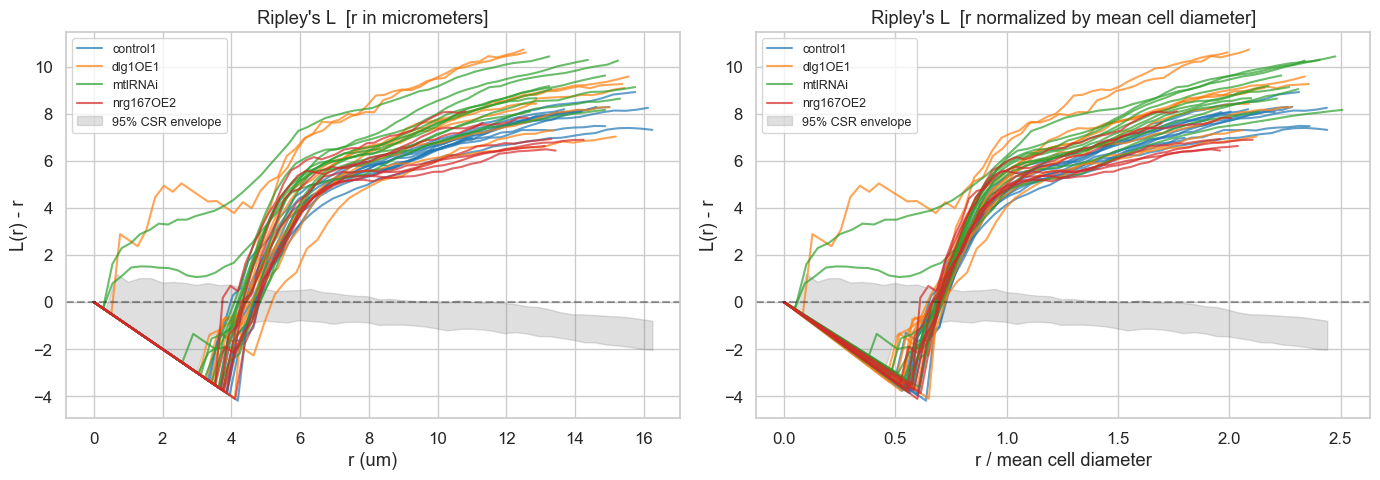

In [53]:
# Ripley's L — r in micrometers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cond_colors = {c: col for c, col in zip(conditions_unique,
               sns.color_palette('tab10', len(conditions_unique)))}

for entry in ripley_per_sample:
    r   = entry['r']
    L   = entry['L_observed']
    r_n = entry['r_normalized']
    color = cond_colors[entry['condition']]

    axes[0].plot(r, L, color=color, alpha=0.7, linewidth=1.5, label=entry['condition'])
    if r_n is not None:
        axes[1].plot(r_n, L, color=color, alpha=0.7, linewidth=1.5, label=entry['condition'])

# Draw CSR envelope from first sample (representative)
ref = ripley_per_sample[0]
axes[0].fill_between(ref['r'], ref['L_envelope_lo'], ref['L_envelope_hi'],
                     color='gray', alpha=0.25, label='95% CSR envelope')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[0].set_xlabel('r (um)')
axes[0].set_ylabel("L(r) - r")
axes[0].set_title("Ripley's L  [r in micrometers]")

if ref['r_normalized'] is not None:
    axes[1].fill_between(ref['r_normalized'], ref['L_envelope_lo'], ref['L_envelope_hi'],
                         color='gray', alpha=0.25, label='95% CSR envelope')
    axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
    axes[1].set_xlabel('r / mean cell diameter')
    axes[1].set_ylabel("L(r) - r")
    axes[1].set_title("Ripley's L  [r normalized by mean cell diameter]")
else:
    axes[1].set_visible(False)

# Deduplicate legend entries
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ripleys_L.pdf'), bbox_inches='tight')
plt.show()

## 11. Export — Painted Label Maps

Saves metric-painted volumes for visual inspection in napari or Fiji.

In [ ]:
metrics_to_paint = [
    'shared_boundary_ratio',
    'vasa_neighbors',
    'clustering_coeff',
    'cluster_size',
    'equivalent_diameter_um',
]

for folder, condition in zip(folders, conditions):
    mask_files = sorted([
        f for f in os.listdir(folder)
        if f.endswith('masks_refined.tif')
    ])
    for fname in mask_files:
        dataset = fname.split('_ch')[0]
        label_image = tifffile.imread(os.path.join(folder, fname))
        cm = df_cells[df_cells['dataset'] == dataset].copy()

        for metric in metrics_to_paint:
            if metric not in cm.columns:
                continue
            painted = sat.paintLabelsByMetric(label_image, cm, metric)
            out_path = os.path.join(output_dir, f'{dataset}_{metric}_map.tif')
            tifffile.imwrite(out_path, painted)
            print(f'  Saved {out_path}')